Customer Tier Distribution:
customer_tier
Bronze      0.4995
Silver      0.3010
Gold        0.1510
Platinum    0.0485
Name: proportion, dtype: float64

Country Distribution:
country
USA      0.4058
EU       0.3055
Asia     0.1926
Other    0.0961
Name: proportion, dtype: float64

Correlation:
                         age       CLV  next_purchase_prob
age                 1.000000 -0.005475            0.004220
CLV                -0.005475  1.000000            0.007426
next_purchase_prob  0.004220  0.007426            1.000000


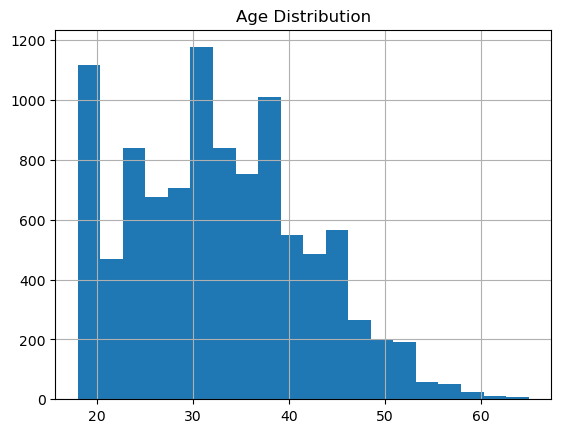

In [6]:
# Step 0: Imports and setup
import pandas as pd
import numpy as np
from faker import Faker
import random
import matplotlib.pyplot as plt

# Seeds for reproducibility
Faker.seed(42)
np.random.seed(42)
random.seed(42)
fake = Faker()

# Step 1A: Number of customers
num_customers = 10000

# Step 1B: Customer IDs
customer_ids = np.arange(1, num_customers + 1)

# Step 1C: Country distribution
countries = ['USA', 'EU', 'Asia', 'Other']
country_probs = [0.4, 0.3, 0.2, 0.1]
customer_country = np.random.choice(countries, size=num_customers, p=country_probs)

# Step 1D: Names and genders
names = [fake.name() for _ in range(num_customers)]
genders = np.random.choice(['M','F','Other'], size=num_customers, p=[0.49,0.49,0.02])

# Step 1E: Age distribution (realistic)
ages = np.clip(np.random.normal(33, 10, num_customers), 18, 65).astype(int)

# Step 1F: Customer tier
tiers = ['Bronze','Silver','Gold','Platinum']
tier_probs = [0.5,0.3,0.15,0.05]
customer_tier = np.random.choice(tiers, size=num_customers, p=tier_probs)

# Step 1G: Signup dates with realistic seasonality

years = np.random.choice([2019,2020,2021,2022,2023], size=num_customers)
months = np.zeros(num_customers, dtype=int)

# Correct month probability arrays per country
usa_probs  = np.array([0.05]*9 + [0.10, 0.25, 0.15]); usa_probs /= usa_probs.sum()
eu_probs   = np.array([0.05]*7 + [0.10,0.10,0.10,0.25,0.10,0.05]); eu_probs = eu_probs[:12]; eu_probs /= eu_probs.sum()
asia_probs = np.array([0.05]*10 + [0.30,0.15]); asia_probs /= asia_probs.sum()

# Assign months
for i, c in enumerate(customer_country):
    if c == 'USA':
        months[i] = np.random.choice(np.arange(1,13), p=usa_probs)
    elif c == 'EU':
        months[i] = np.random.choice(np.arange(1,13), p=eu_probs)
    elif c == 'Asia':
        months[i] = np.random.choice(np.arange(1,13), p=asia_probs)
    else:
        months[i] = np.random.randint(1,13)

# Assign days (1-28 to simplify)
days = np.random.randint(1,29, size=num_customers)
signup_dates = pd.to_datetime(dict(year=years, month=months, day=days))

# Step 1H: Assemble DataFrame
customer_profiles = pd.DataFrame({
    'customer_id': customer_ids,
    'name': names,
    'gender': genders,
    'age': ages,
    'country': customer_country,
    'signup_date': signup_dates,
    'customer_tier': customer_tier
})

# Step 2: Placeholder target features

# Months since signup
customer_profiles['months_since_signup'] = (pd.Timestamp('2024-01-01') - customer_profiles['signup_date']).dt.days // 30

# Churn: inactive >24 months, with randomness
customer_profiles['churned'] = np.where(
    (customer_profiles['months_since_signup'] > 24) & (np.random.rand(num_customers) > 0.3),
    True, False
)

# CLV: correlated with tier
tier_multiplier = {'Bronze': 1, 'Silver': 1.5, 'Gold': 2, 'Platinum': 3}
customer_profiles['CLV'] = customer_profiles['customer_tier'].map(tier_multiplier) * np.random.normal(100, 20, num_customers)

# Next purchase probability: placeholder
customer_profiles['next_purchase_prob'] = np.clip(np.random.normal(0.5, 0.15, num_customers), 0, 1)

# Step 3: Validation - distribution and correlations
print("Customer Tier Distribution:")
print(customer_profiles['customer_tier'].value_counts(normalize=True))

print("\nCountry Distribution:")
print(customer_profiles['country'].value_counts(normalize=True))

print("\nCorrelation:")
print(customer_profiles[['age','CLV','next_purchase_prob']].corr())

# Step 4: Histogram for age
customer_profiles['age'].hist(bins=20)
plt.title('Age Distribution')
plt.show()

# Step 5: Save CSV
customer_profiles.to_csv('../data/customer_profiles_10k.csv', index=False)